In [37]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
FILE_PATH = 'dataset/figma-data/cleaned/cleaning_report.json'

with open(FILE_PATH, "r", encoding="utf-8") as f:
    report = json.load(f)

summary = report["summary"]

In [39]:
df = pd.DataFrame(report["files"])

df["group"] = df["filename"].str.extract(r"^(hard|medium|simple)[/\\]", expand=False)

df["file_label"] = df["filename"].str.replace("\\", "/", regex=False)

summary, df.head(3)

({'total_files': 30,
  'average_reduction_percent': 84.08,
  'average_attributes_before': 3999.83,
  'average_attributes_after': 644.07},
        filename  size_before  size_after  reduction_percent  \
 0   hard\1.json       110741       17005              84.64   
 1  hard\10.json       233758       40720              82.58   
 2   hard\2.json       144889       21432              85.21   
 
    attributes_before  attributes_after                     name group  \
 0               4798               796  1 [Bearbeitungs-Dialog]  hard   
 1              10476              1907   10 [Admin-Panel-Liste]  hard   
 2               6477              1022       2 [Nutzer-Tabelle]  hard   
 
      file_label  
 0   hard/1.json  
 1  hard/10.json  
 2   hard/2.json  )

### Reduction per File

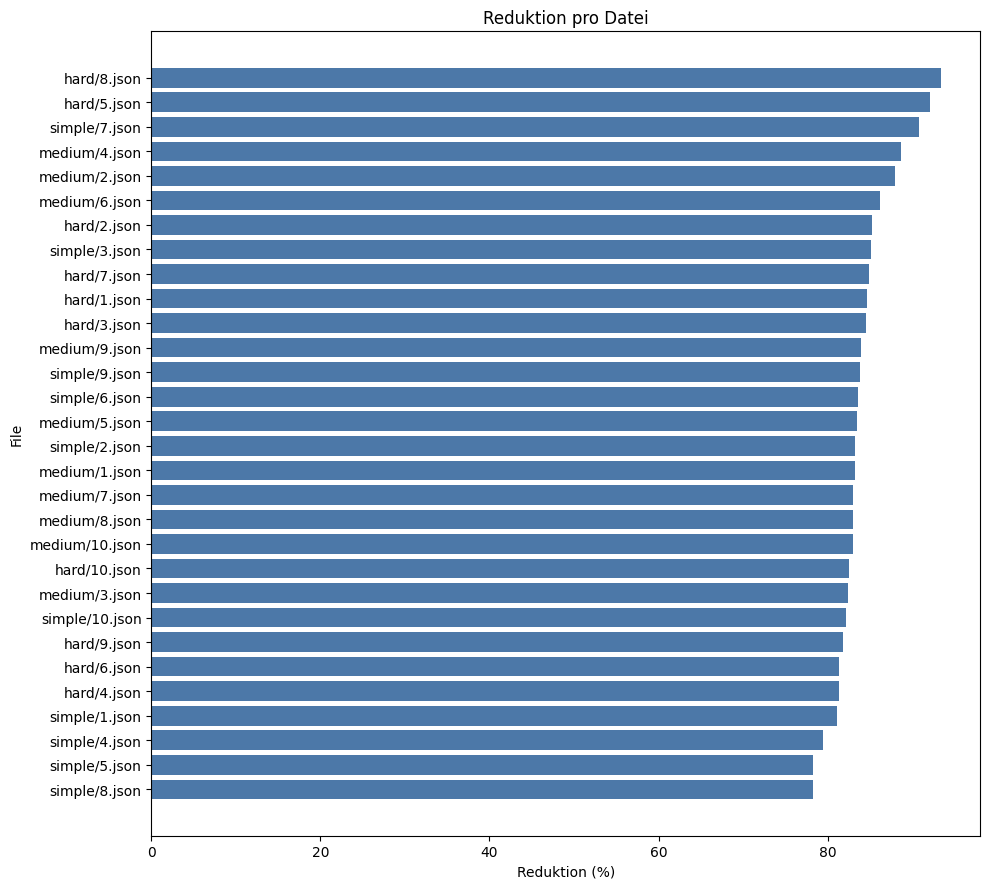

In [40]:
plot_df = df.sort_values("reduction_percent", ascending=True)

plt.figure(figsize=(10, 9))
plt.barh(plot_df["file_label"], plot_df["reduction_percent"], color="#4C78A8")
plt.xlabel("Reduktion (%)")
plt.ylabel("File")
plt.title("Reduktion pro Datei")
plt.tight_layout()
plt.show()

### Reduction Distribution by Group

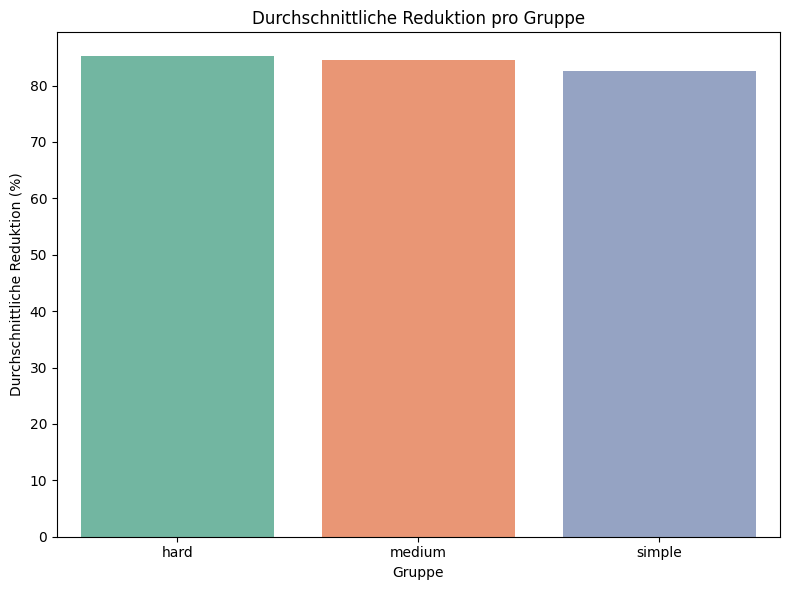

In [41]:
group_summary = df.groupby("group")["reduction_percent"].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(
    x="group",
    y="reduction_percent",
    hue="group",
    data=group_summary,
    palette="Set2",
    legend=False,
)
plt.xlabel("Gruppe")
plt.ylabel("Durchschnittliche Reduktion (%)")
plt.title("Durchschnittliche Reduktion pro Gruppe")
plt.tight_layout()
plt.show()

### Reduction Distribution

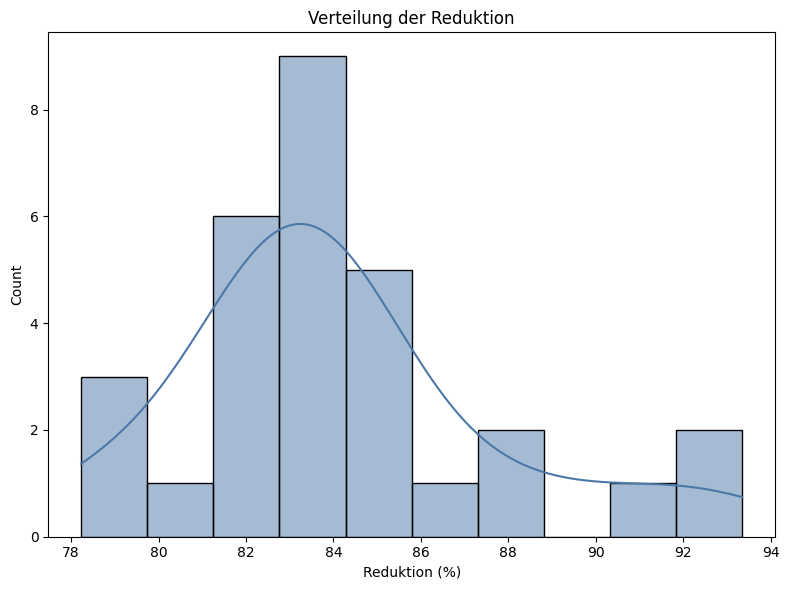

In [42]:
plt.figure(figsize=(8, 6))
sns.histplot(df["reduction_percent"], bins=10, kde=True, color="#4C78A8")
plt.xlabel("Reduktion (%)")
plt.title("Verteilung der Reduktion")
plt.tight_layout()
plt.show()

### Reduction Distribution by Group

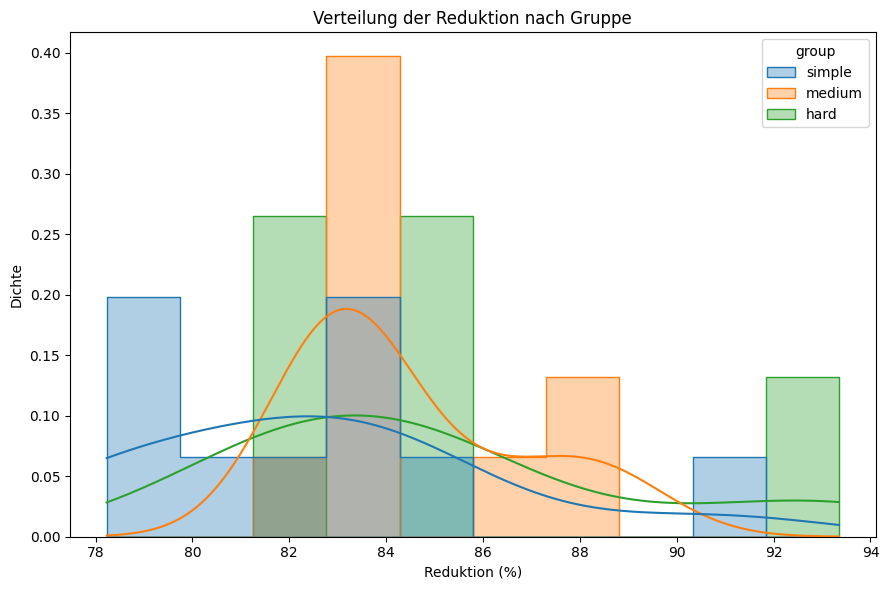

In [43]:
plt.figure(figsize=(9, 6))
sns.histplot(
    data=df,
    x="reduction_percent",
    hue="group",
    hue_order=["simple", "medium", "hard"],
    bins=10,
    kde=True,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.35,
)
plt.xlabel("Reduktion (%)")
plt.ylabel("Dichte")
plt.title("Verteilung der Reduktion nach Gruppe")
plt.tight_layout()
plt.show()

### Attributes before and after

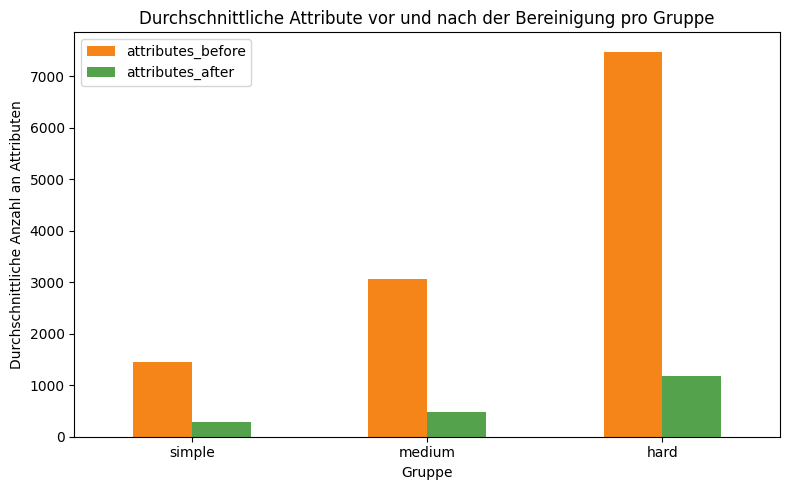

In [44]:
grp = df.groupby("group", as_index=False)[["attributes_before", "attributes_after"]].mean()
grp = grp.set_index("group").reindex(["simple", "medium", "hard"]).reset_index()

ax = grp.plot(
    x="group",
    y=["attributes_before", "attributes_after"],
    kind="bar",
    figsize=(8, 5),
    rot=0,
    color=["#F58518", "#54A24B"]
)
ax.set_title("Durchschnittliche Attribute vor und nach der Bereinigung pro Gruppe")
ax.set_xlabel("Gruppe")
ax.set_ylabel("Durchschnittliche Anzahl an Attributen")
plt.tight_layout()
plt.show()